# Quality Evaluation Results


In [160]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from plot_utils import colors, set_plot_style, set_legend_style

RESULTS_DIR = os.path.join('results', 'quality', 'front')

In [161]:
set_plot_style()

In [162]:
results = {}

for filename in os.listdir(os.path.join(RESULTS_DIR, 'path_tracing')):
    volume, extinction, transfer_function = filename[:-4].rsplit('_', 2)
    results[(volume, int(extinction), int(transfer_function))] = {
        'path_tracing': pd.read_csv(
            os.path.join(RESULTS_DIR, 'path_tracing', filename)
        ),
        'neural_render': pd.read_csv(
            os.path.join(RESULTS_DIR, 'neural_render', filename)
        ),
    }

## Plots

In [163]:
def plot_quality_metrics(results, volume, extinction, transfer_function, metric):
    pt = results[(volume, extinction, transfer_function)]['path_tracing']
    nr = results[(volume, extinction, transfer_function)]['neural_render']

    runs = len(pt['run'].unique())

    # Use the smallest run size to handle timing differences
    min_n_pt = pt.groupby('run').size().min()
    min_n_nr = nr.groupby('run').size().min()
    n = min(min_n_pt, min_n_nr)

    # Trim each run to n rows, then concatenate
    pt = pd.concat([grp.iloc[:n] for _, grp in pt.groupby('run')]).reset_index(
        drop=True
    )
    nr = pd.concat([grp.iloc[:n] for _, grp in nr.groupby('run')]).reset_index(
        drop=True
    )

    times = pt[pt['run'] == pt['run'].unique()[0]]['time'].to_numpy()

    stats_pt = (
        pt[[metric + '_global', metric + '_indirect']].to_numpy().reshape(runs, n, 2)
    )
    stats_nr = (
        nr[[metric + '_global', metric + '_indirect']].to_numpy().reshape(runs, n, 2)
    )

    mu_pt = stats_pt.mean(axis=0)
    mu_nr = stats_nr.mean(axis=0)
    se_pt = stats_pt.std(axis=0) / np.sqrt(runs)
    se_nr = stats_nr.std(axis=0) / np.sqrt(runs)

    fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

    ax[0].plot(times, mu_pt[:, 0], label='Path Tracing')
    ax[0].fill_between(
        times, mu_pt[:, 0] - se_pt[:, 0], mu_pt[:, 0] + se_pt[:, 0], alpha=0.2
    )
    ax[0].plot(times, mu_nr[:, 0], label='Neural Render')
    ax[0].fill_between(
        times, mu_nr[:, 0] - se_nr[:, 0], mu_nr[:, 0] + se_nr[:, 0], alpha=0.2
    )
    ax[0].set_title('Global ' + metric.upper())
    ax[0].set_xlabel('Time [s]')
    ax[0].set_ylabel(metric.upper())
    ax[0].legend()

    ax[1].plot(times, mu_pt[:, 1], label='Path Tracing')
    ax[1].fill_between(
        times, mu_pt[:, 1] - se_pt[:, 1], mu_pt[:, 1] + se_pt[:, 1], alpha=0.2
    )
    ax[1].plot(times, mu_nr[:, 1], label='Neural Render')
    ax[1].fill_between(
        times, mu_nr[:, 1] - se_nr[:, 1], mu_nr[:, 1] + se_nr[:, 1], alpha=0.2
    )
    ax[1].set_title('Indirect ' + metric.upper())
    ax[1].set_xlabel('Time [s]')

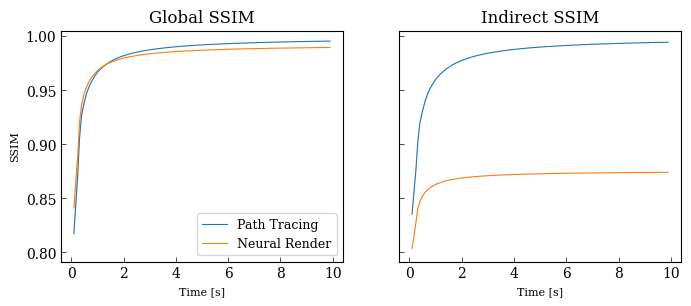

In [164]:
plot_quality_metrics(results, 'chameleon', 80, 3, 'ssim')

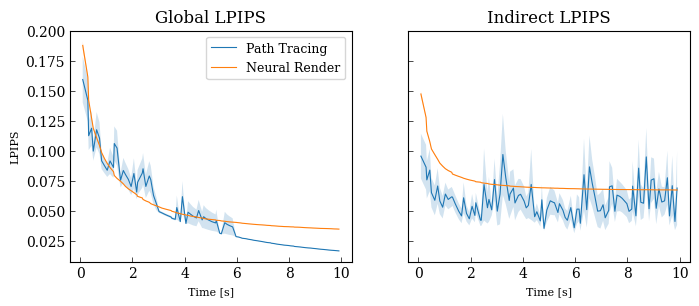

In [165]:
plot_quality_metrics(results, 'chameleon', 200, 3, 'lpips')

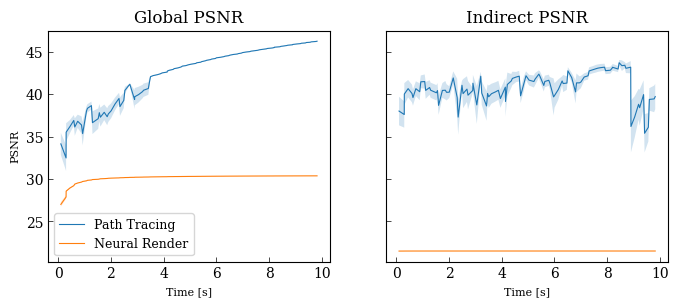

In [166]:
plot_quality_metrics(results, 'chameleon', 1000, 2, 'psnr')

## Table

In [167]:
def compute_metric(results, volume, extinction, transfer_function, column, time):
    pt = results[(volume, extinction, transfer_function)]['path_tracing']
    nr = results[(volume, extinction, transfer_function)]['neural_render']

    # Find the closest time entry for each run (there are some time variations)
    pt = pt.groupby('run').apply(lambda df: df.iloc[(df['time'] - time).abs().argmin()])
    nr = nr.groupby('run').apply(lambda df: df.iloc[(df['time'] - time).abs().argmin()])

    pt = pt[[column]]
    nr = nr[[column]]

    mu_pt = pt.mean().to_numpy()[0].item()
    mu_nr = nr.mean().to_numpy()[0].item()
    se_pt = (pt.std().to_numpy()[0] / np.sqrt(len(pt))).item()
    se_nr = (nr.std().to_numpy()[0] / np.sqrt(len(nr))).item()

    return (mu_pt, se_pt), (mu_nr, se_nr)

In [168]:
volumes = sorted({volume for volume, _, _ in results.keys()})
extinctions = sorted({extinction for _, extinction, _ in results.keys()})
transfer_functions = sorted(
    {transfer_function for _, _, transfer_function in results.keys()}
)


def print_volume_table(results, volume, extinctions, transfer_functions, time):
    print(f'Volume: {volume}')
    print(
        f'{"Ext.":<5} {"TF":<4} {"SSIM PT":<18} {"SSIM NR":<18} {"LPIPS PT":<18} {"LPIPS NR":<18} {"PSNR PT":<15} {"PSNR NR":<15}'
    )
    for extinction in extinctions:
        for transfer_function in transfer_functions:
            pt_ssim, nr_ssim = compute_metric(
                results, volume, extinction, transfer_function, 'ssim_global', time
            )
            pt_lpips, nr_lpips = compute_metric(
                results, volume, extinction, transfer_function, 'lpips_global', time
            )
            pt_psnr, nr_psnr = compute_metric(
                results, volume, extinction, transfer_function, 'psnr_global', time
            )

            print(
                f'{extinction:<5} {transfer_function:<4} '
                f'{pt_ssim[0]:.4f} ± {pt_ssim[1]:.4f}    '
                f'{nr_ssim[0]:.4f} ± {nr_ssim[1]:.4f}    '
                f'{pt_lpips[0]:.4f} ± {pt_lpips[1]:.4f}    '
                f'{nr_lpips[0]:.4f} ± {nr_lpips[1]:.4f}    '
                f'{pt_psnr[0]:.2f} ± {pt_psnr[1]:.2f}    '
                f'{nr_psnr[0]:.2f} ± {nr_psnr[1]:.2f}'
            )

In [169]:
print_volume_table(results, 'chameleon', extinctions, transfer_functions, 0.2)

Volume: chameleon
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
80    1    0.9102 ± 0.0057    0.8953 ± 0.0116    0.1723 ± 0.0043    0.1806 ± 0.0074    35.89 ± 0.36    34.31 ± 0.53
80    2    0.9135 ± 0.0141    0.9344 ± 0.0030    0.1465 ± 0.0089    0.1234 ± 0.0030    32.24 ± 0.74    33.13 ± 0.20
80    3    0.8716 ± 0.0120    0.8888 ± 0.0129    0.1628 ± 0.0071    0.1439 ± 0.0078    31.68 ± 0.56    31.13 ± 0.49
200   1    0.8667 ± 0.0123    0.8668 ± 0.0030    0.1869 ± 0.0076    0.1821 ± 0.0019    33.32 ± 0.63    32.18 ± 0.11
200   2    0.8665 ± 0.0076    0.9082 ± 0.0047    0.1752 ± 0.0046    0.1417 ± 0.0036    30.48 ± 0.39    32.45 ± 0.25
200   3    0.8200 ± 0.0111    0.8605 ± 0.0032    0.1892 ± 0.0061    0.1615 ± 0.0019    29.83 ± 0.50    30.40 ± 0.11
1000  1    0.8301 ± 0.0077    0.8177 ± 0.0079    0.1994 ± 0.0045    0.1919 ± 0.0043    31.64 ± 0.37    28.86 ± 0.22
1000  2    0.7561 ± 0.0060    0.8104 ± 0.0095    0.

In [170]:
print_volume_table(results, 'chameleon', extinctions, transfer_functions, 5)

Volume: chameleon
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
80    1    0.9939 ± 0.0000    0.9864 ± 0.0000    0.0230 ± 0.0001    0.0427 ± 0.0002    49.60 ± 0.02    39.60 ± 0.00
80    2    0.9952 ± 0.0000    0.9941 ± 0.0000    0.0127 ± 0.0001    0.0127 ± 0.0001    46.48 ± 0.02    40.25 ± 0.00
80    3    0.9920 ± 0.0000    0.9871 ± 0.0000    0.0167 ± 0.0002    0.0223 ± 0.0001    46.01 ± 0.02    35.92 ± 0.00
200   1    0.9907 ± 0.0000    0.9745 ± 0.0000    0.0326 ± 0.0002    0.0547 ± 0.0003    47.64 ± 0.02    36.24 ± 0.00
200   2    0.9907 ± 0.0000    0.9906 ± 0.0000    0.0256 ± 0.0003    0.0203 ± 0.0001    44.58 ± 0.01    39.30 ± 0.00
200   3    0.9846 ± 0.0001    0.9759 ± 0.0000    0.0339 ± 0.0002    0.0429 ± 0.0001    43.94 ± 0.02    34.86 ± 0.00
1000  1    0.9867 ± 0.0001    0.9563 ± 0.0000    0.0410 ± 0.0002    0.0671 ± 0.0002    46.14 ± 0.02    31.69 ± 0.00
1000  2    0.9767 ± 0.0001    0.9536 ± 0.0000    0.

In [171]:
print_volume_table(results, 'chameleon', extinctions, transfer_functions, 10)

Volume: chameleon
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
80    1    0.9964 ± 0.0000    0.9889 ± 0.0000    0.0106 ± 0.0001    0.0315 ± 0.0001    52.10 ± 0.01    39.79 ± 0.00
80    2    0.9973 ± 0.0000    0.9957 ± 0.0000    0.0061 ± 0.0001    0.0082 ± 0.0000    49.15 ± 0.01    40.62 ± 0.00
80    3    0.9955 ± 0.0000    0.9896 ± 0.0000    0.0078 ± 0.0001    0.0170 ± 0.0001    48.68 ± 0.01    36.08 ± 0.00
200   1    0.9947 ± 0.0000    0.9785 ± 0.0000    0.0159 ± 0.0002    0.0420 ± 0.0001    50.28 ± 0.01    36.38 ± 0.00
200   2    0.9948 ± 0.0000    0.9931 ± 0.0000    0.0124 ± 0.0001    0.0131 ± 0.0001    47.31 ± 0.01    39.68 ± 0.00
200   3    0.9915 ± 0.0000    0.9799 ± 0.0000    0.0168 ± 0.0002    0.0350 ± 0.0001    46.71 ± 0.01    35.02 ± 0.00
1000  1    0.9925 ± 0.0000    0.9620 ± 0.0000    0.0218 ± 0.0001    0.0545 ± 0.0002    48.85 ± 0.01    31.77 ± 0.00
1000  2    0.9871 ± 0.0001    0.9596 ± 0.0000    0.